# Trabajo Práctico Integrado — Probabilidad y Estadística
## Análisis estadístico de las contrataciones públicas del Paraguay (DNCP, 2021–2022)

*Maestría en Ciencia de Datos · Análisis de una base de datos de acceso abierto*

---

## 1. Descripción del dataset y el problema

**Fuente.** Portal de la **Dirección Nacional de Contrataciones Públicas (DNCP)** del Paraguay — datos abiertos publicados en el estándar internacional **OCDS** (*Open Contracting Data Standard*). Cita: DNCP, *Datos Abiertos de Contrataciones*, https://www.contrataciones.gov.py/datos.

**Contexto.** Cada registro corresponde a un **proceso de contratación pública adjudicado** durante los años **2021 y 2022**. Los archivos (`records_contratos_2021.csv`, `records_contratos_2022.csv`) contienen, para cada llamado, el monto, la modalidad y método de contratación, la categoría del bien/servicio/obra, la institución compradora, el número de oferentes y las fechas del proceso.

**Población relevada.** La totalidad de los procesos de contratación cargados en el portal DNCP para 2021–2022 (39.957 registros crudos), de los cuales trabajamos con los **efectivamente completados y adjudicados**.

**Pregunta de investigación.** *En las contrataciones públicas adjudicadas del Paraguay (2021–2022): ¿cómo se distribuyen los montos adjudicados y el nivel de competencia? ¿Difieren significativamente el monto y la competencia entre 2021 y 2022 y entre las categorías de compra? ¿Qué variables explican el monto adjudicado?*


### Preparación del entorno y carga de datos

In [1]:
# Dependencias (en Colab descomentar la línea siguiente)
# %pip install -q pandas numpy scipy statsmodels seaborn matplotlib gdown==5.2.0

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

In [2]:
# Descarga automática del dataset (solo si no está en ./data). En Colab usa gdown desde la
# carpeta pública de Google Drive; localmente basta con tener los CSV en la carpeta data/.
URL_DATASET = 'https://drive.google.com/drive/folders/1738grWDl9j2VXf3ju0JFq0Njo2WXiQGo'
os.makedirs('data', exist_ok=True)
faltan = [f for f in ['records_contratos_2021.csv', 'records_contratos_2022.csv']
          if not os.path.exists(os.path.join('data', f))]
if faltan:
    import gdown
    gdown.download_folder(url=URL_DATASET, output='data', quiet=False)
else:
    print('CSV ya presentes en ./data:', os.listdir('data'))

CSV ya presentes en ./data: ['records_contratos_2022.csv', 'README.md', 'records_contratos_2021.csv']


**Nota sobre los archivos.** El portal publica los mismos registros bajo dos endpoints (`contratos` y `adjudicaciones`); una verificación de duplicados mostró que son **idénticos**, por lo que se usan únicamente los archivos de **contratos**. Además, los CSV de 2021 y 2022 traen las mismas 66 columnas OCDS pero **en distinto orden**, de modo que el renombrado se hace **por nombre** (no por posición) y se recupera la columna `anio` al cargar cada archivo por separado.

In [3]:
# ---------- Carga y limpieza (pipeline reproducible) ----------
COLUMNAS_RAW = [
    'Open Contracting ID','compiledRelease/id','compiledRelease/tender/id',
    'compiledRelease/tender/title','compiledRelease/tender/status',
    'compiledRelease/tender/awardCriteria','compiledRelease/tender/awardCriteriaDetails',
    'compiledRelease/tender/submissionMethod','compiledRelease/tender/bidOpening/date',
    'compiledRelease/tender/bidOpening/address/streetAddress',
    'compiledRelease/tender/submissionMethodDetails','compiledRelease/tender/eligibilityCriteria',
    'compiledRelease/tender/statusDetails','compiledRelease/tender/enquiriesAddress/streetAddress',
    'compiledRelease/tender/mainProcurementCategoryDetails','compiledRelease/tender/hasEnquiries',
    'compiledRelease/tender/value/amount','compiledRelease/tender/value/currency',
    'compiledRelease/tender/datePublished','compiledRelease/tender/tenderPeriod/startDate',
    'compiledRelease/tender/tenderPeriod/endDate','compiledRelease/tender/tenderPeriod/durationInDays',
    'compiledRelease/tender/awardPeriod/startDate','compiledRelease/tender/contractPeriod/maxExtentDate',
    'compiledRelease/tender/enquiryPeriod/endDate','compiledRelease/tender/enquiryPeriod/startDate',
    'compiledRelease/tender/enquiryPeriod/durationInDays','compiledRelease/tender/mainProcurementCategory',
    'compiledRelease/tender/procurementMethod','compiledRelease/tender/procurementMethodDetails',
    'compiledRelease/tender/procuringEntity/id','compiledRelease/tender/procuringEntity/name',
    'compiledRelease/language','compiledRelease/ocid','compiledRelease/date',
    'compiledRelease/initiationType','compiledRelease/buyer/id','compiledRelease/buyer/name',
    'compiledRelease/planning/identifier','compiledRelease/planning/estimatedDate',
    'compiledRelease/planning/budget/description','compiledRelease/planning/budget/amount/currency',
    'compiledRelease/planning/budget/amount/amount','compiledRelease/tag',
    'compiledRelease/tender/contractPeriod/durationInDays','compiledRelease/tender/coveredBy',
    'compiledRelease/tender/additionalProcurementCategories','compiledRelease/tender/numberOfTenderers',
    'compiledRelease/tender/techniques/hasElectronicAuction','compiledRelease/tender/procurementIntention/id',
    'compiledRelease/tender/procurementIntention/uri','compiledRelease/tender/procurementIntention/category',
    'compiledRelease/tender/procurementIntention/title','compiledRelease/tender/procurementIntention/description',
    'compiledRelease/tender/procurementIntention/startDate','compiledRelease/tender/procurementIntention/publishedDate',
    'compiledRelease/tender/procurementIntention/procuringEntity/id',
    'compiledRelease/tender/procurementIntention/procuringEntity/name',
    'compiledRelease/tender/procurementIntention/status','compiledRelease/tender/procurementIntention/statusDetails',
    'compiledRelease/tender/procurementMethodRationale','compiledRelease/tender/procurementIntention/rationale',
    'compiledRelease/secondStage/id','compiledRelease/tender/techniques/hasFrameworkAgreement',
    'compiledRelease/tender/contractPeriod/startDate','compiledRelease/tender/contractPeriod/endDate',
]
COLUMNAS_ES = [
    'id_contratacion','id','id_licitacion','titulo','estado','criterio_adjudicacion',
    'forma_adjudicacion','forma_presentacion','fecha_apertura_ofertas','direccion',
    'detalles_metodo_envio','criterio_elegibilidad','detalle_estado','direccion2',
    'categoria_detallada','hubo_consultas','monto_licitado','moneda','fecha_publicacion',
    'fecha_inicio_licitacion','fecha_fin_licitacion','duracion_dias_licitacion',
    'fecha_inicio_adjudicacion','fecha_max_extension_contrato','fecha_fin_consultas',
    'fecha_inicio_consultas','duracion_dias_consultas','tipo_bien_servicio','metodo_contratacion',
    'modalidad','id_convocante','convocante','idioma','ocid','fecha_compilacion','tipo_iniciacion',
    'id_comprador','institucion','planificacion_id','planificacion_fecha_estimada',
    'planificacion_presupuesto_descripcion','planificacion_presupuesto_moneda',
    'planificacion_presupuesto_monto','etiqueta','contrato_duracion_dias','regimen_especial',
    'categorias_adicionales','num_oferentes','es_subasta_electronica','intencion_id','intencion_uri',
    'intencion_categoria','intencion_titulo','intencion_descripcion','intencion_fecha_inicio',
    'intencion_fecha_publicacion','intencion_entidad_id','intencion_entidad_nombre','intencion_estado',
    'intencion_detalle_estado','justificacion_metodo','intencion_justificacion','segunda_etapa_id',
    'tiene_acuerdo_marco','contrato_fecha_inicio','contrato_fecha_fin',
]
RENAME_MAP = dict(zip(COLUMNAS_RAW, COLUMNAS_ES))
TIPO_CAMBIO = 7200  # PYG/USD promedio 2021-2022

def _leer(ruta, anio):
    d = pd.read_csv(ruta, low_memory=False).rename(columns=RENAME_MAP)[COLUMNAS_ES]
    d['anio'] = anio
    return d

def cargar_y_limpiar(carpeta='data'):
    df = pd.concat([_leer(os.path.join(carpeta,'records_contratos_2021.csv'), 2021),
                    _leer(os.path.join(carpeta,'records_contratos_2022.csv'), 2022)],
                   ignore_index=True).drop_duplicates()
    # 1) Descartar texto libre / identificadores / columnas casi vacías
    df = df.drop(columns=[
        'idioma','tipo_iniciacion','etiqueta','es_subasta_electronica','intencion_estado',
        'intencion_detalle_estado','intencion_justificacion','tiene_acuerdo_marco','segunda_etapa_id',
        'direccion','direccion2','criterio_elegibilidad','detalles_metodo_envio',
        'planificacion_presupuesto_descripcion','justificacion_metodo','intencion_id','intencion_uri',
        'intencion_categoria','intencion_titulo','intencion_descripcion','intencion_fecha_inicio',
        'intencion_fecha_publicacion','intencion_entidad_id','intencion_entidad_nombre','id_comprador',
        'id_convocante','id_contratacion','id','contrato_fecha_inicio','contrato_fecha_fin'], errors='ignore')
    # 2) Fechas -> datetime
    fechas = ['fecha_apertura_ofertas','fecha_publicacion','fecha_inicio_licitacion','fecha_fin_licitacion',
              'fecha_inicio_adjudicacion','fecha_max_extension_contrato','fecha_fin_consultas',
              'fecha_inicio_consultas','fecha_compilacion','planificacion_fecha_estimada']
    for c in fechas:
        if c in df: df[c] = pd.to_datetime(df[c], errors='coerce')
    # 3) float -> Int64  4) drop columnas con >25.000 nulos
    for c in df.select_dtypes(include='float').columns: df[c] = df[c].astype('Int64')
    nulos = df.isna().sum(); df = df.drop(columns=nulos[nulos > 25000].index, errors='ignore')
    # 5) filtros: procesos completos y adjudicados
    df = df[(df['estado']=='complete') & (df['detalle_estado']=='Adjudicada')].copy()
    # 6) monto a USD (PYG/tc; USD se deja igual)
    monto = pd.to_numeric(df['monto_licitado'], errors='coerce').astype('float64')
    df['monto_usd'] = monto.where(df['moneda']=='USD', monto/TIPO_CAMBIO).round(2)
    # 7) variables derivadas para el análisis
    df['tipo_es'] = df['tipo_bien_servicio'].map({'goods':'Bienes','services':'Servicios','works':'Obras'})
    df['competencia'] = (df['num_oferentes'] > 1).astype('Int64')  # 1 = más de un oferente
    return df

df = cargar_y_limpiar('data')
print('Dataset limpio:', df.shape, '| por año:', dict(df['anio'].value_counts()))

Dataset limpio: (23982, 37) | por año: {2022: np.int64(18567), 2021: np.int64(5415)}


## 2. Identificación y clasificación de variables

Se seleccionan **6 variables** (3 cuantitativas y 3 cualitativas) para el análisis:

| Variable | Descripción | Tipo | Escala | Codificación |
|---|---|---|---|---|
| `monto_usd` | Monto adjudicado del proceso, convertido a USD (tc = 7.200 PYG/USD) | Cuantitativa **continua** | Razón | Real positivo; se analiza su `log₁₀` |
| `num_oferentes` | Cantidad de oferentes que se presentaron al llamado | Cuantitativa **discreta** | Razón | Entero ≥ 1 |
| `duracion_dias_licitacion` | Duración del período de licitación (días) | Cuantitativa **discreta** | Razón | Entero ≥ 0 |
| `tipo_es` | Categoría principal de la compra | Cualitativa **nominal** | Nominal | Bienes / Servicios / Obras |
| `modalidad` | Modalidad del proceso de contratación | Cualitativa **nominal** | Nominal | Contratación Directa, Concurso de Ofertas, Licitación Pública Nacional, … |
| `anio` | Año del proceso | Cualitativa **nominal** (binaria) | Nominal | 2021 / 2022 |

**Variable binarizada.** A partir de `num_oferentes` se define **`competencia`** (cualitativa nominal binaria): vale **1** si hubo *competencia efectiva* (más de un oferente) y **0** si se presentó un único oferente. Se usa para la estimación e inferencia sobre proporciones.

**Reflexión (por qué `monto_usd` es continua).** Aunque expresada en dinero, puede tomar cualquier valor real positivo; su fuerte asimetría a derecha se corrige con la transformación logarítmica, habitual para variables monetarias.

## 3. Limpieza y preparación de los datos

El pipeline de la celda anterior deja documentado el proceso; a continuación se cuantifican los tres aspectos exigidos.

In [4]:
# --- Valores faltantes (variables del análisis) ---
analisis = ['monto_usd','num_oferentes','duracion_dias_licitacion','tipo_es','modalidad','anio','competencia']
print('VALORES FALTANTES por variable:')
print(df[analisis].isna().sum())
print(f"\nDataset final: {df.shape[0]:,} observaciones y {df.shape[1]} variables")

VALORES FALTANTES por variable:
monto_usd                    112
num_oferentes               1124
duracion_dias_licitacion    1191
tipo_es                        0
modalidad                      0
anio                           0
competencia                 1124
dtype: int64

Dataset final: 23,982 observaciones y 37 variables


In [5]:
# --- Valores atípicos en monto_usd (regla del rango intercuartílico, IQR) ---
m = df['monto_usd'].dropna()
q1, q3 = m.quantile([.25, .75]); iqr = q3 - q1
lim_sup = q3 + 1.5*iqr
n_out = (m > lim_sup).sum()
print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}  límite superior={lim_sup:,.0f}")
print(f"Outliers por encima del límite: {n_out:,} ({n_out/len(m)*100:.1f}% de los montos)")
print(f"Máximo: {m.max():,.0f} USD  |  asimetría (skew): {m.skew():.1f}")

Q1=10,914  Q3=49,722  IQR=38,809  límite superior=107,935
Outliers por encima del límite: 3,186 (13.3% de los montos)
Máximo: 73,151,373 USD  |  asimetría (skew): 27.0


In [6]:
# --- Transformación: log10 del monto (para montos > 0) y subconjunto de análisis de montos ---
dfa = df[df['monto_usd'].notna() & (df['monto_usd'] > 0)].copy()
dfa['log_monto'] = np.log10(dfa['monto_usd'])
print(f"Subconjunto con monto>0 para análisis monetario: {len(dfa):,} filas "
      f"(se excluyen {len(df)-len(dfa):,} con monto nulo o cero)")

Subconjunto con monto>0 para análisis monetario: 23,853 filas (se excluyen 129 con monto nulo o cero)


**Criterios adoptados.**
- **Faltantes.** `num_oferentes` (y por ende `competencia`) tiene **1.124** faltantes y `duracion_dias_licitacion` **1.191**; `tipo_es`, `modalidad` y `anio` no tienen faltantes. Se aplica **eliminación por lista** *en cada análisis* (se descartan los casos faltantes solo en las variables involucradas), preservando el máximo de información en cada prueba.
- **Atípicos.** El monto presenta **asimetría extrema** (coeficiente de variación > 800%): por la regla IQR, un porcentaje relevante de contratos supera el límite superior. **No se eliminan** —son contratos reales (grandes obras públicas)— sino que se **transforma con `log₁₀`**, que comprime la escala y aproxima la distribución a la normal para las pruebas paramétricas.
- **Transformaciones.** Conversión de moneda a USD; `log₁₀(monto_usd)`; recuperación de `anio`; binarización de `competencia`; mapeo de `tipo` a español (Bienes/Servicios/Obras).
- **Dataset final: 23.982 observaciones** (18.567 de 2022 y 5.415 de 2021).

## 4. Análisis descriptivo y gráficos

In [7]:
# --- Estadísticos descriptivos de las variables cuantitativas ---
def resumen(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    return pd.Series({'n':len(s),'media':s.mean(),'mediana':s.median(),'desv_est':s.std(),
                      'mín':s.min(),'máx':s.max(),'CV_%':s.std()/s.mean()*100})
tabla = pd.DataFrame({c: resumen(df[c]) for c in ['monto_usd','num_oferentes','duracion_dias_licitacion']}).T
tabla

,n,media,mediana,desv_est,mín,máx,CV_%
monto_usd,"23,870.00","174,044.35","19,974.26","1,466,580.77",0.00,"73,151,373.18",842.65
num_oferentes,"22,858.00",2.73,2.00,2.44,1.00,43.00,89.48
duracion_dias_licitacion,"22,791.00",13.29,10.00,15.31,0.00,728.00,115.15


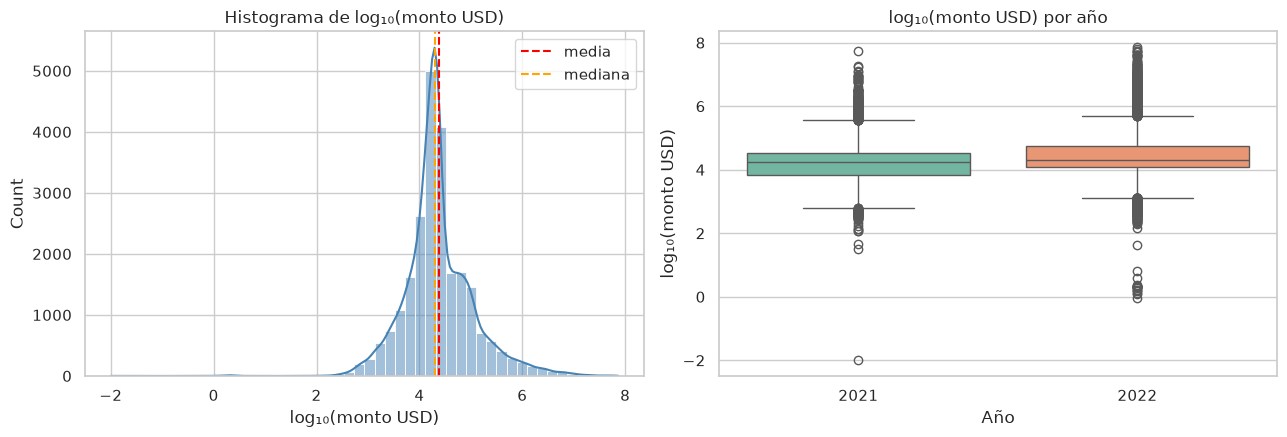

In [8]:
# Gráfico 1 — Distribución del monto (escala log) y por año
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(dfa['log_monto'], bins=50, kde=True, color='steelblue', ax=ax[0])
ax[0].axvline(dfa['log_monto'].mean(), color='red', ls='--', label='media')
ax[0].axvline(dfa['log_monto'].median(), color='orange', ls='--', label='mediana')
ax[0].set(title='Histograma de log₁₀(monto USD)', xlabel='log₁₀(monto USD)'); ax[0].legend()
sns.boxplot(data=dfa, x='anio', y='log_monto', hue='anio', palette='Set2', legend=False, ax=ax[1])
ax[1].set(title='log₁₀(monto USD) por año', xlabel='Año', ylabel='log₁₀(monto USD)')
plt.tight_layout(); plt.show()

**Interpretación (Gráfico 1).** En escala logarítmica el monto es **aproximadamente simétrico y unimodal**, centrado en torno a `log₁₀ ≈ 4,37` (≈ **23.500 USD**, media geométrica). La cercanía entre media y mediana en la escala log confirma que la transformación corrige la fuerte asimetría original (en escala natural la media, 174.044 USD, multiplica por ~9 a la mediana, 19.974 USD). El boxplot por año muestra montos algo **mayores en 2022**.

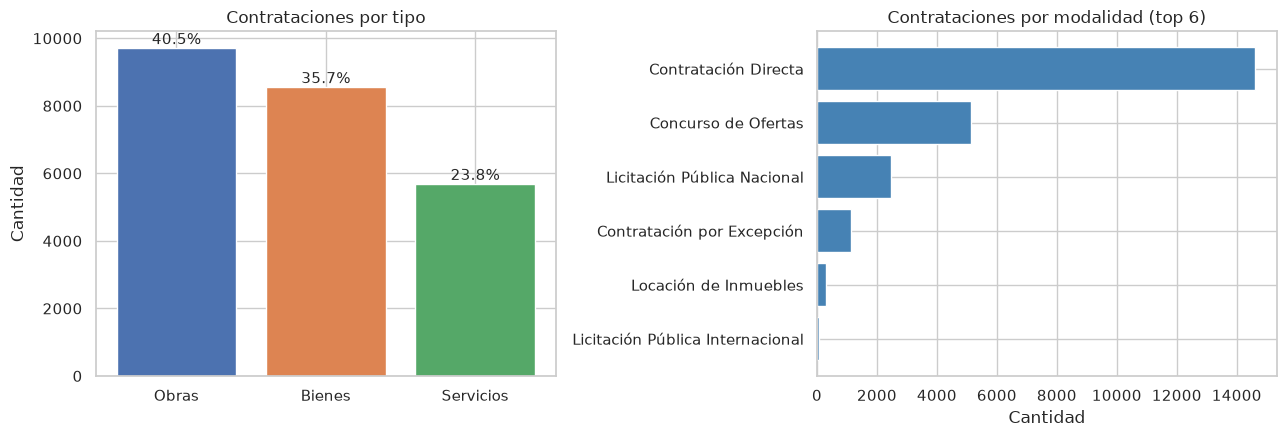

Tipo (%):
tipo_es
Obras       40.50
Bienes      35.70
Servicios   23.80
Name: proportion, dtype: float64

Modalidad (%):
modalidad
Contratación Directa               60.90
Concurso de Ofertas                21.40
Licitación Pública Nacional        10.30
Contratación por Excepción          4.80
Locación de Inmuebles               1.30
Licitación Pública Internacional    0.30
Name: proportion, dtype: float64


In [9]:
# Gráfico 2 — Variables cualitativas: tipo y modalidad
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
tc = df['tipo_es'].value_counts()
ax[0].bar(tc.index, tc.values, color=['#4c72b0','#dd8452','#55a868'])
ax[0].set(title='Contrataciones por tipo', ylabel='Cantidad')
for i,v in enumerate(tc.values): ax[0].text(i, v, f'{v/len(df)*100:.1f}%', ha='center', va='bottom')
mc = df['modalidad'].value_counts().head(6)[::-1]
ax[1].barh(mc.index, mc.values, color='steelblue')
ax[1].set(title='Contrataciones por modalidad (top 6)', xlabel='Cantidad')
plt.tight_layout(); plt.show()

print('Tipo (%):'); print((df['tipo_es'].value_counts(normalize=True)*100).round(1))
print('\nModalidad (%):'); print((df['modalidad'].value_counts(normalize=True)*100).round(1).head(6))

**Interpretación (Gráfico 2).** Las **Obras** son la categoría más frecuente (40,5%), seguidas de **Bienes** (35,7%) y **Servicios** (23,8%): las tres tienen tamaños muestrales amplios, adecuados para comparaciones entre grupos. En modalidad domina de forma marcada la **Contratación Directa** (≈61%), seguida del **Concurso de Ofertas** (≈21%) y la **Licitación Pública Nacional** (≈10%); las modalidades competitivas de mayor cuantía son minoritarias en número de procesos.

## 5. Estimación por intervalos de confianza (95%)

In [10]:
# 5a — IC 95% para la media de log10(monto). n es grande => t ≈ z.
x = dfa['log_monto']; n = len(x); media = x.mean(); ee = x.std(ddof=1)/np.sqrt(n)
tcrit = stats.t.ppf(0.975, n-1)
li, ls = media - tcrit*ee, media + tcrit*ee
print(f"n={n:,}  media(log)={media:.4f}  EE={ee:.5f}  t*={tcrit:.4f}")
print(f"IC95% (log10): ({li:.4f} ; {ls:.4f})")
print(f"IC95% en USD (media geométrica): {10**media:,.0f}  ->  ({10**li:,.0f} ; {10**ls:,.0f})")

n=23,853  media(log)=4.3715  EE=0.00438  t*=1.9601
IC95% (log10): (4.3629 ; 4.3800)
IC95% en USD (media geométrica): 23,521  ->  (23,061 ; 23,991)


**5a — Interpretación.** Con un **95% de confianza**, la **media geométrica** del monto adjudicado de la población de contrataciones se encuentra entre **23.061 y 23.991 USD** (media puntual ≈ 23.521). El intervalo es **muy angosto** (~930 USD de amplitud) porque el tamaño muestral es grande (n ≈ 23.900), lo que otorga gran precisión a la estimación. *Correctamente*: si repitiéramos el muestreo muchas veces, el 95% de los intervalos así construidos contendrían la verdadera media poblacional.

In [11]:
# 5b — IC 95% para la proporción de procesos con competencia (>1 oferente)
comp = df['competencia'].dropna().astype(int)
k, n = comp.sum(), len(comp); phat = k/n
ee = np.sqrt(phat*(1-phat)/n); z = stats.norm.ppf(0.975)
print(f"éxitos={k:,}  n={n:,}  p̂={phat:.4f}")
print(f"IC95% (aprox. normal): ({phat-z*ee:.4f} ; {phat+z*ee:.4f})")
print(f"IC95% (Wilson):        {tuple(round(v,4) for v in proportion_confint(k, n, method='wilson'))}")

éxitos=14,833  n=22,858  p̂=0.6489
IC95% (aprox. normal): (0.6427 ; 0.6551)
IC95% (Wilson):        (0.6427, 0.6551)


**5b — Interpretación.** Con un **95% de confianza**, la proporción poblacional de contrataciones con **competencia efectiva** (más de un oferente) está entre **64,3% y 65,5%** (estimación puntual 64,9%). Ambos métodos (aproximación normal y Wilson) coinciden hasta el cuarto decimal, gracias al gran `n`. Esto indica que **cerca de un tercio de los procesos recibe una única oferta**, un hallazgo relevante en términos de transparencia y concurrencia.

## 6. Prueba de hipótesis

Se comparan **dos grupos definidos por el año** (2021 vs 2022), con **α = 0,05** en ambas pruebas.

### 6a. Diferencia de medias — prueba *t* de Welch sobre `log₁₀(monto)`

- **H₀:** μ₂₀₂₁ = μ₂₀₂₂  (el monto medio, en escala log, no difiere entre años)
- **H₁:** μ₂₀₂₁ ≠ μ₂₀₂₂  (**contraste bilateral**: no se presume a priori en qué dirección cambia)
- Se usa **t de Welch** porque no se asume igualdad de varianzas entre los grupos.

In [12]:
g21 = dfa[dfa['anio']==2021]['log_monto']; g22 = dfa[dfa['anio']==2022]['log_monto']
t, p = stats.ttest_ind(g21, g22, equal_var=False)
print(f"2021: n={len(g21):,}  media(log)={g21.mean():.4f}  (USD geom {10**g21.mean():,.0f})")
print(f"2022: n={len(g22):,}  media(log)={g22.mean():.4f}  (USD geom {10**g22.mean():,.0f})")
print(f"\nEstadístico t = {t:.3f}   valor p = {p:.3e}")
print('Decisión:', 'se RECHAZA H0' if p < 0.05 else 'no se rechaza H0')

2021: n=5,378  media(log)=4.2294  (USD geom 16,958)
2022: n=18,475  media(log)=4.4128  (USD geom 25,871)

Estadístico t = -17.214   valor p = 2.690e-65
Decisión: se RECHAZA H0


**6a — Conclusión.** t = −17,2 con **p ≈ 2,7×10⁻⁶⁵ < 0,05** ⇒ **se rechaza H₀**. Existe evidencia estadística muy fuerte de que el **monto medio adjudicado aumentó** de 2021 (≈ 16.958 USD, media geométrica) a 2022 (≈ 25.871 USD). La diferencia es además de magnitud práctica considerable (+53% en la media geométrica).

### 6b. Diferencia de proporciones — prueba *z* sobre `competencia`

- **H₀:** p₂₀₂₁ = p₂₀₂₂  (la proporción de procesos con competencia no difiere entre años)
- **H₁:** p₂₀₂₁ ≠ p₂₀₂₂  (**contraste bilateral**)
- Prueba **z para diferencia de proporciones** (muestras grandes).

In [13]:
c21 = df[df['anio']==2021]['competencia'].dropna().astype(int)
c22 = df[df['anio']==2022]['competencia'].dropna().astype(int)
count = np.array([c21.sum(), c22.sum()]); nobs = np.array([len(c21), len(c22)])
z, p = proportions_ztest(count, nobs)
print(f"2021: p̂={count[0]/nobs[0]:.4f}  (n={nobs[0]:,})")
print(f"2022: p̂={count[1]/nobs[1]:.4f}  (n={nobs[1]:,})")
print(f"\nEstadístico z = {z:.3f}   valor p = {p:.3e}")
print('Decisión:', 'se RECHAZA H0' if p < 0.05 else 'no se rechaza H0')

2021: p̂=0.7247  (n=5,169)
2022: p̂=0.6268  (n=17,689)

Estadístico z = 12.977   valor p = 1.663e-38
Decisión: se RECHAZA H0


**6b — Conclusión.** z = 12,98 con **p ≈ 1,7×10⁻³⁸ < 0,05** ⇒ **se rechaza H₀**. La proporción de procesos con competencia efectiva **cayó** de **72,5% (2021)** a **62,7% (2022)**. Es decir, en 2022 hubo montos mayores pero **menor concurrencia** de oferentes, combinación que amerita atención desde la perspectiva de la eficiencia del gasto público.

## 7. Regresión lineal múltiple

Se estudia **qué variables explican el monto adjudicado**. La variable respuesta es **log₁₀(monto)**, en escala logarítmica por la fuerte asimetría del monto ya justificada en la sección 3.

- **Modelo:** `log₁₀(monto) ~ num_oferentes + duracion_dias_licitacion + C(tipo_es) + C(modalidad)`
- **Hipótesis global (prueba F):** H₀: todos los coeficientes de pendiente son 0 (el modelo no explica nada) vs. H₁: al menos un coeficiente es distinto de 0.
- **Hipótesis por coeficiente (prueba t):** H₀: βⱼ = 0 vs. H₁: βⱼ ≠ 0, para cada predictor.

Primero se muestra el diagrama de dispersión de una regresión simple ilustrativa (monto vs. número de oferentes) y luego se estima el modelo múltiple.

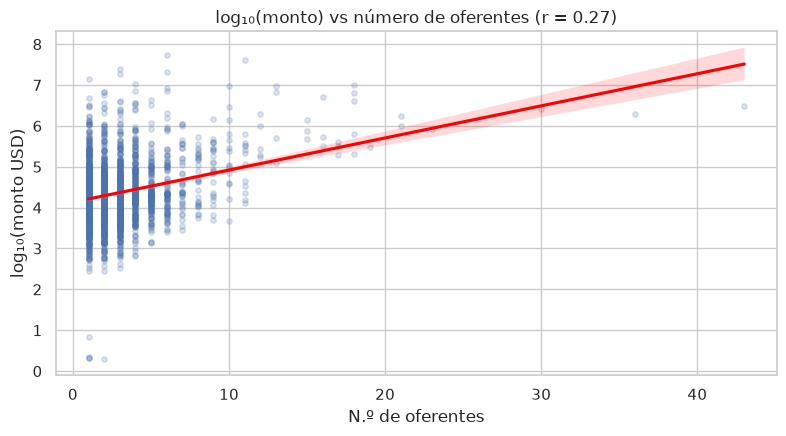

In [17]:
# Gráfico 3 — Diagrama de dispersión (regresión simple ilustrativa: log_monto vs num_oferentes)
sub = dfa.dropna(subset=['num_oferentes']).copy()
sub['num_oferentes'] = sub['num_oferentes'].astype(float)
plt.figure(figsize=(8, 4.5))
sns.regplot(data=sub.sample(3000, random_state=1), x='num_oferentes', y='log_monto',
            scatter_kws={'alpha':0.2, 's':15}, line_kws={'color':'red'})
r, _ = stats.pearsonr(sub['num_oferentes'], sub['log_monto'])
plt.title(f'log₁₀(monto) vs número de oferentes (r = {r:.2f})')
plt.xlabel('N.º de oferentes'); plt.ylabel('log₁₀(monto USD)'); plt.tight_layout(); plt.show()

In [18]:
# Modelo múltiple (modalidad colapsada a top-5 + "Otras")
top5 = dfa['modalidad'].value_counts().head(5).index
dfr = dfa.copy()
dfr['modalidad_g'] = np.where(dfr['modalidad'].isin(top5), dfr['modalidad'], 'Otras')
dfr['num_oferentes'] = pd.to_numeric(dfr['num_oferentes'], errors='coerce')
dfr['duracion_dias_licitacion'] = pd.to_numeric(dfr['duracion_dias_licitacion'], errors='coerce')
dfr = dfr.dropna(subset=['log_monto','num_oferentes','duracion_dias_licitacion','tipo_es','modalidad_g'])
reg = ols('log_monto ~ num_oferentes + duracion_dias_licitacion + C(tipo_es) + C(modalidad_g)', data=dfr).fit()
print(f"n={int(reg.nobs):,}   R²={reg.rsquared:.3f}   R²_aj={reg.rsquared_adj:.3f}"
      f"   F={reg.fvalue:,.0f}   p(F)={reg.f_pvalue:.2e}\n")
print(reg.summary().tables[1])

n=22,465   R²=0.663   R²_aj=0.663   F=4,914   p(F)=0.00e+00

                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         4.5333      0.008    579.788      0.000       4.518       4.549
C(tipo_es)[T.Obras]                               0.2357      0.006     39.515      0.000       0.224       0.247
C(tipo_es)[T.Servicios]                           0.0563      0.007      7.978      0.000       0.042       0.070
C(modalidad_g)[T.Contratación Directa]           -0.7093      0.006   -110.235      0.000      -0.722      -0.697
C(modalidad_g)[T.Contratación por Excepción]      0.7472      0.100      7.456      0.000       0.551       0.944
C(modalidad_g)[T.Licitación Pública Nacional]     0.8477      0.010     84.771      0.000       0.828       0.867
C(modalidad_g)[T.Locación d

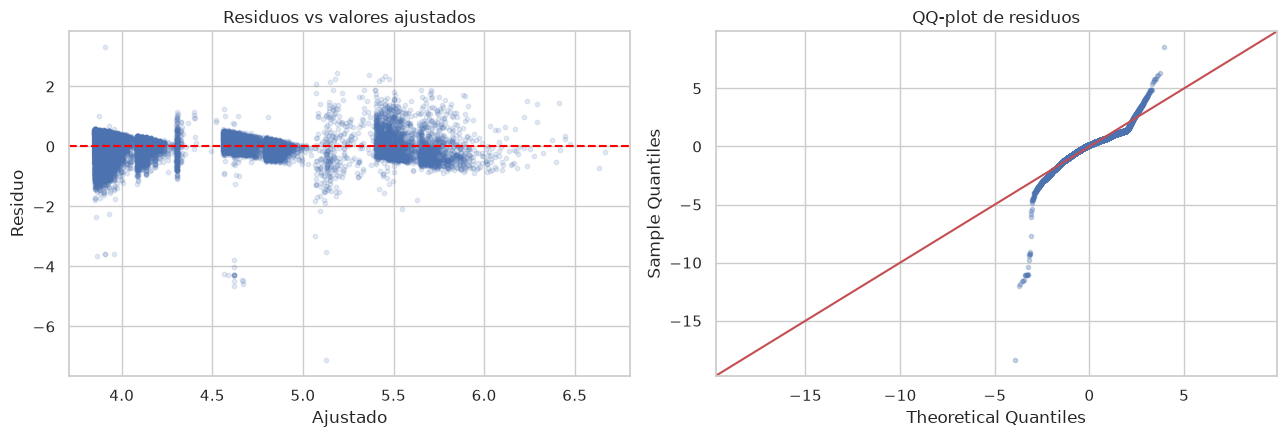

In [19]:
# Gráfico 4 — Diagnóstico de residuos
resid, fitted = reg.resid, reg.fittedvalues
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(fitted, resid, alpha=0.15, s=10); ax[0].axhline(0, color='red', ls='--')
ax[0].set(title='Residuos vs valores ajustados', xlabel='Ajustado', ylabel='Residuo')
sm.qqplot(resid, line='45', fit=True, ax=ax[1], markersize=3, alpha=0.3)
ax[1].set_title('QQ-plot de residuos')
plt.tight_layout(); plt.show()

**Interpretación y conclusión.** El modelo explica el **66,3% de la variabilidad** del log-monto (**R² = 0,663**) y la **prueba F global es altamente significativa** (F ≈ 4.914; p ≈ 0), por lo que el conjunto de predictores es relevante. Todos los coeficientes son significativos (p < 0,01). Lecturas destacadas (cada coeficiente es el cambio en log₁₀ del monto, *ceteris paribus*):
- **Modalidad** es el factor de mayor peso: respecto de *Concurso de Ofertas* (categoría base), la **Contratación Directa** se asocia a montos **mucho menores** (−0,71 en log₁₀ ≈ **−80%**), mientras que la **Licitación Pública Nacional** se asocia a montos **mayores** (+0,85 ≈ **×7**). Coherente: los procesos competitivos formales canalizan las compras de mayor cuantía.
- **N.º de oferentes:** +0,024 por oferente adicional ⇒ cada oferente extra se asocia a ≈ **+5,7%** de monto (relación positiva pero débil, r = 0,28).
- **Tipo:** las **Obras** implican mayor monto que Bienes (+0,24 en log₁₀, ≈ +72%), a igualdad del resto de factores.
- Los residuos (Gráfico 4) están razonablemente centrados en cero; el QQ-plot muestra colas algo pesadas, limitación esperable dada la naturaleza de los datos.

## 8. Resumen ejecutivo

Se analizaron **23.982 contrataciones públicas adjudicadas** del Paraguay (portal DNCP, 2021–2022). Los montos adjudicados son muy dispares: la mitad de los procesos no supera los **~20.000 USD**, pero unos pocos contratos de gran envergadura (obras) elevan fuertemente el promedio. Estimamos, con 95% de confianza, que el **monto típico** (media geométrica) de una contratación ronda los **23.000–24.000 USD**, y que **aproximadamente 2 de cada 3 procesos** reciben más de una oferta.

Al comparar años surgen dos señales claras y estadísticamente significativas: entre 2021 y 2022 el **monto típico creció** (de ≈17.000 a ≈26.000 USD), mientras que la **competencia disminuyó** (del 72% al 63% de procesos con más de un oferente). En otras palabras, se contrató por montos mayores pero con menos concurrencia.

Finalmente, el **tipo de compra** y sobre todo la **modalidad** son determinantes del monto: las **obras** y las **licitaciones públicas** concentran los importes más altos, mientras que la **contratación directa** —la modalidad más frecuente— se asocia a montos mucho menores. Un modelo estadístico con estas variables explica cerca de **dos tercios** de la variación de los montos. Estos resultados ofrecen una base cuantitativa para monitorear la **transparencia y la eficiencia** del gasto público paraguayo.

---
*Fuente de datos: Dirección Nacional de Contrataciones Públicas (DNCP), Paraguay — datos abiertos en estándar OCDS. Período 2021–2022.*